# Inferencia estadística vs Aprendizaje de máquinas

Pía Amigo, 2026

### Parte 1: Ajuste de recta

(Adaptado de Viviana Acquaviva (2023))

**Objetivo:** Resolver el mismo problema con dos estrategias distintas y comparar sus resultados.

**Nombre(s):** Cristóbal Castro Riquelme

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Parámetros para figuras de alta calidad
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 150

np.random.seed(16)  # semilla fija para reproducibilidad

x = np.arange(10)
y = 2*x + 5 + np.random.randn(10)  # datos con scatter gaussiano
y = np.round(y, 1)

Los datos corresponden al movimiento de un auto con rapidez constante,
donde el eje $x$ es tiempo (en segundos) y el eje $y$ es distancia (en metros).

**Pregunta:** A partir de estos datos queremos predecir $d(t=12\text{ s})$.
Antes de escribir código: ¿cómo resolverías este problema? Describe tu estrategia con palabras.

**Tu respuesta:** A partir de los datos se calcula la recta que mejor represente al conjunto de datos encontrando la que minize la distancia de todos los datos a ella (minimos cuadrados)

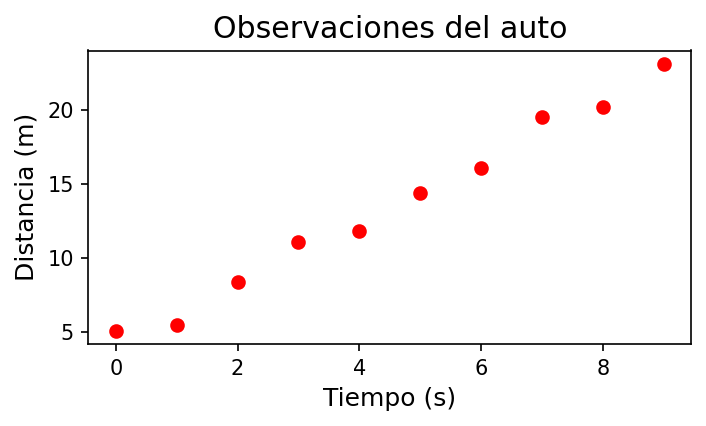

In [2]:
# Visualiza los datos
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Observaciones del auto')
plt.tight_layout()

## Parte 1: Inferencia estadística

Sabemos que la relación entre distancia y tiempo para un auto con rapidez constante es:
$$d = d_0 + v \cdot t$$

Este modelo tiene dos parámetros: $d_0$ (posición inicial) y $v$ (velocidad).
Nuestro objetivo es **encontrar los valores de $d_0$ y $v$** que mejor explican los datos.

### 1a. Búsqueda por grilla

Una estrategia es probar muchas combinaciones de parámetros y quedarse con la que
minimiza el **error cuadrático medio (MSE) (Mínimos cuadrados)**:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2$$

In [3]:
# Definimos la grilla de parámetros a explorar
m_range = np.linspace(0, 5, 100)   # posibles velocidades
b_range = np.linspace(0, 10, 100)  # posibles posiciones iniciales

best_mse = np.inf
bestm, bestb = 0, 0

# Completa el loop: para cada combinación (m, b),
# calcula el MSE y guarda los mejores parámetros
for m in m_range:
    for b in b_range:
        y_pre = m * x + b
        m_mse = np.mean((y - y_pre)**2)
        if m_mse < best_mse:
            best_mse = m_mse
            bestm = m
            bestb = b 



print(f'Mejor pendiente (velocidad):     {bestm:.3f} m/s')
print(f'Mejor intercepto (pos. inicial): {bestb:.3f} m')
print(f'MSE mínimo: {best_mse:.4f}')
print(f'Distancia en t = 12 s: {bestm * 12 + bestb:.2f} m')

Mejor pendiente (velocidad):     2.071 m/s
Mejor intercepto (pos. inicial): 4.242 m
MSE mínimo: 0.3699
Distancia en t = 12 s: 29.09 m


<details>
<summary>Ayuda</summary>

Dentro del loop calcula la predicción y el MSE:
```python
y_pred = m * x + b
mse = np.mean((y - y_pred)**2)
```
Luego comparas con `best_mse` y actualizas si encontraste algo mejor.
</details>

**¿Cuáles son los valores encontrados? ¿Son razonables físicamente?**
Con este modelo, ¿cuánto vale $d(t=12\text{ s})$?

- `bestm` = 2.071 m/s
- `bestb` = 4.242 m
- $d(t=12)$ = 29.09

Los datos si son razonables ya que los valores reales de la velocidad y posición incial son 2 m/s y 5 m respectivamente y los valores calculados se se aproximan a estos numeros bastante bien considerando el tamaño reducido de la muestra.


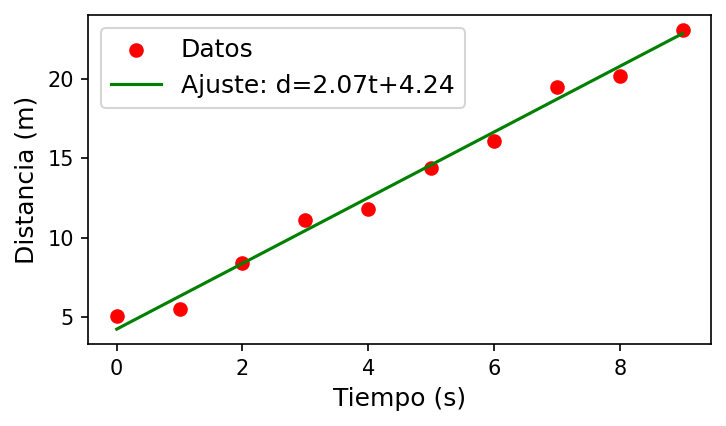

In [4]:
# Grafica los datos y la recta con los mejores parámetros
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red', label='Datos')
plt.plot(x, bestm*x + bestb, c='g', label=f'Ajuste: d={bestm:.2f}t+{bestb:.2f}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()

### 1b. Ajuste con incertezas

En astronomía las mediciones siempre tienen incertezas.
Cuando las incluimos, los puntos más precisos (menor $\sigma_i$) deben tener
**más peso** en el ajuste. La función a minimizar se convierte en el $\chi^2$:

$$\chi^2 = \sum_{i=1}^{N} \frac{(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2}{\sigma_i^2}$$

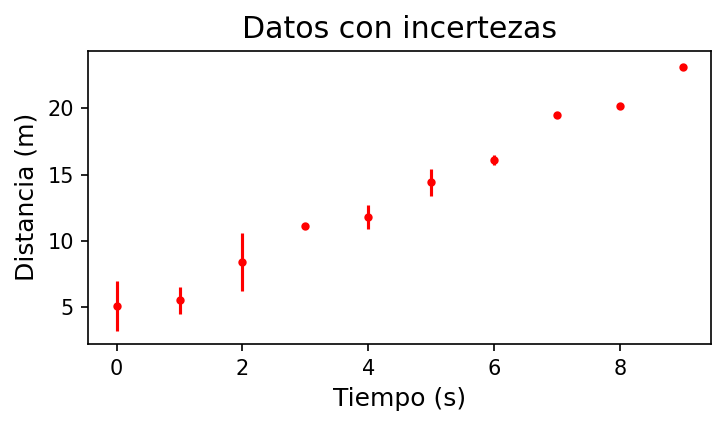

In [5]:
np.random.seed(10)
dy = np.random.randn(10) * np.sqrt(2)  # incertezas aleatorias

plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Datos con incertezas')
plt.tight_layout()

In [6]:
best_chi2 = np.inf
bestm_werr, bestb_werr = 0, 0

for m in m_range:
    for b in b_range:
        chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2)
        if chi2 < best_chi2:
            best_chi2 = chi2
            bestm_werr = m
            bestb_werr = b

print(f'Mejor pendiente (con incertezas):  {bestm_werr:.3f} m/s')
print(f'Mejor intercepto (con incertezas): {bestb_werr:.3f} m')

Mejor pendiente (con incertezas):  1.818 m/s
Mejor intercepto (con incertezas): 5.657 m


<details>
<summary> Ayuda</summary>

```python
chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2)
```
</details>

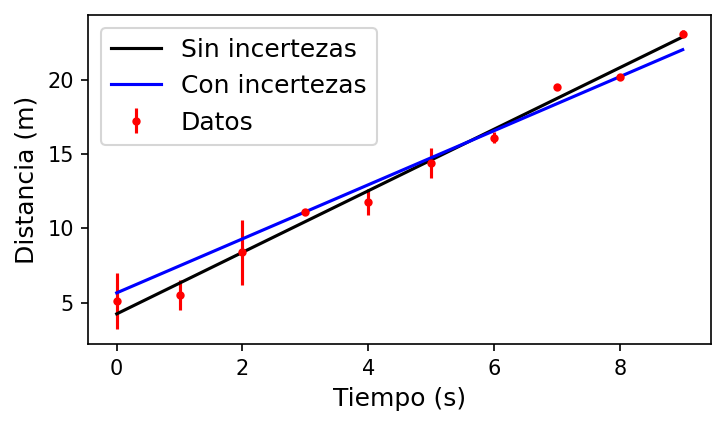

In [7]:
# Comparamos ambos ajustes
plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ', label='Datos')
plt.plot(x, bestb + bestm * x, c='black', label='Sin incertezas')
plt.plot(x, bestb_werr + bestm_werr * x, c='b', label='Con incertezas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()

**Pregunta: ¿Cambiaron mucho los parámetros al incluir incertezas? ¿Tiene sentido ese cambio?**

**Tu respuesta:**
Si los parametros cambio su pendiente ligeramente al añadir las incertesas y el cambio si tiene sentido ya que antes de los 6 segundos es donde se encuentran los datos con incertezas considerables y cuando se realiza el chi_cuadrado los datos con mas incerteza se toman menos en cuenta.



## Parte 2: Machine Learning

En ML **no asumimos la forma del modelo**. Le damos los datos a un algoritmo
y él aprende la relación entre input ($t$) y output ($d$) directamente.

Probaremos dos modelos:
- [**Regresión lineal**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) (`LinearRegression`): aprende la misma recta, pero sin que nosotros definamos el modelo físico.
- [**kNN Regressor**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) (`KNeighborsRegressor`): predice el valor de un punto nuevo como el **promedio de sus $k$ vecinos más cercanos**. No asume ninguna forma funcional.



### 2a. División train/test

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

np.random.seed(10)
# y_train = targets 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=3)

print(f'Entrenamiento: {X_train} → {y_train}')
print(f'Prueba:        {X_test} → {y_test}')

Entrenamiento: [6 3 1 0 7 4 9] → [16.1 11.1  5.5  5.1 19.5 11.8 23.1]
Prueba:        [8 2 5] → [20.2  8.4 14.4]


**Pregunta:** ¿Por qué separamos los datos en train y test?
¿Qué pasaría si evaluáramos el modelo en los mismos datos con los que lo entrenamos?

**Tu respuesta:** Por que los datos de entrenamiento tienen las caracteristicas para que el modelo aprenda los patrones, si lo evaluaramos con los mismos datos de donde aprendio a identificar los patrones el modelo pareceria perfecto.



### 2b. Entrenar y evaluar ambos modelos

In [9]:
regmodel = LinearRegression()
knnmodel = KNeighborsRegressor(n_neighbors=5)

# Entrenamos con los datos de train y predecimos en test
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
y_pred_knn = knnmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
print('Real:        ', y_test)
print('Reg. Lineal: ', np.round(y_pred_reg, 2))
print('kNN (k=3):   ', np.round(y_pred_knn, 2))

Real:         [20.2  8.4 14.4]
Reg. Lineal:  [20.89  8.42 14.66]
kNN (k=3):    [16.32  9.92 16.32]


<details>
<summary>Ayuda</summary>

El patrón de sklearn siempre es el mismo:
```python
modelo.fit(X_train.reshape(-1,1), y_train).predict(X_test.reshape(-1,1))
```
</details>

In [10]:
# Calculamos el MSE para cada modelo
mse_reg = np.mean((y_test - y_pred_reg)**2)
mse_knn = np.mean((y_test - y_pred_knn)**2)

print(f'MSE Regresión Lineal: {mse_reg:.4f}')
print(f'MSE kNN (k=3):        {mse_knn:.4f}')

MSE Regresión Lineal: 0.1820
MSE kNN (k=3):        7.0171


**Pregunta: ¿Cuál modelo tiene menor MSE? Con solo 3 puntos de test, ¿qué tan confiable es esta comparación?**

**Tu respuesta:** La regresión lineal tiene el menor MSE, con una cantidad tna limitada de datos el MSE no es un buen indicador ya que el tamaño de la muestra produce que el azar juegue un rol importante en los resultados.



### 2c. Predicción fuera del rango de entrenamiento

Ahora la pregunta original: ¿cuánto vale $d(t=12\text{ s})$?

In [11]:
t_nuevo = np.array(12).reshape(-1, 1)

pred_reg = regmodel.predict(t_nuevo)[0]
pred_knn = knnmodel.predict(t_nuevo)[0]
pred_inf = bestm * 12 + bestb

print(f'Inferencia estadística: {pred_inf:.2f} m')
print(f'Regresión lineal (ML):  {pred_reg:.2f} m')
print(f'kNN (k=3):              {pred_knn:.2f} m')
print(f'Valor real (2*12+5):    {2*12+5:.2f} m')

Inferencia estadística: 29.09 m
Regresión lineal (ML):  29.21 m
kNN (k=3):              16.32 m
Valor real (2*12+5):    29.00 m


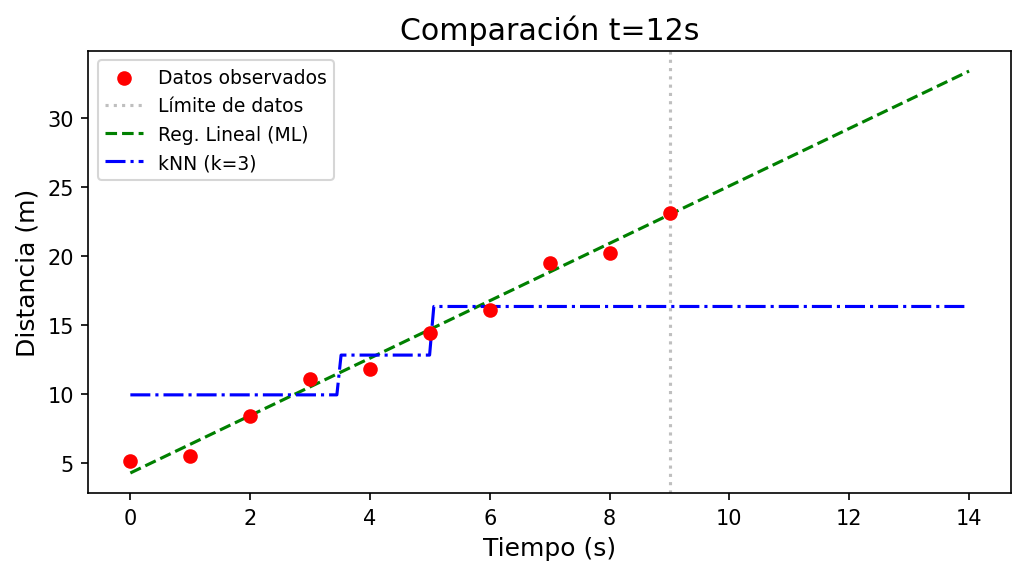

In [12]:
# Visualizamos los tres modelos en rango extendido
t_plot = np.linspace(0, 14, 200).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, c='red', zorder=5, label='Datos observados')
plt.axvline(x=x.max(), color='gray', linestyle=':', alpha=0.5, label='Límite de datos')
#plt.plot(t_plot, bestm * t_plot + bestb, 'k-', label='Inferencia')
plt.plot(t_plot, regmodel.predict(t_plot), 'g--', label='Reg. Lineal (ML)')
plt.plot(t_plot, knnmodel.predict(t_plot), 'b-.', label='kNN (k=3)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Comparación t=12s')
plt.legend(fontsize=9)
plt.tight_layout()

**Pregunta: ¿Qué le pasa a kNN en la zona t > 9? ¿Por qué? ¿Es un problema para este caso?**

**Tu respuesta:** KNN no puede predecir datos fuera del rango con el que fue entrenado (el rango siendo 0-9), cuando esta fuera de rango KNN devuelve el promedio de los datos de entrenamiento mas altos. Para el caso en cuestion si es un problema ya que el objetivo es extrapolar en un rango mayor.



### 2d. ¿Importa el valor de k?

In [13]:
# Prueba distintos valores de k y compara el MSE en test
for k in [1, 2, 3, 5, 7]:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train.reshape(-1, 1), y_train)
    mse = np.mean((y_test - m.predict(X_test.reshape(-1, 1)))**2)
    pred_12 = m.predict([[12]])[0]
    print(f'k={k}  →  MSE test: {mse:.3f}  |  d(t=12): {pred_12:.2f} m')

k=1  →  MSE test: 3.557  |  d(t=12): 23.10 m
k=2  →  MSE test: 0.474  |  d(t=12): 21.30 m
k=3  →  MSE test: 1.241  |  d(t=12): 19.57 m
k=5  →  MSE test: 7.017  |  d(t=12): 16.32 m
k=7  →  MSE test: 24.559  |  d(t=12): 13.17 m


**Pregunta: ¿Cuál k elegirías? ¿Qué criterio usarías para elegirlo de forma sistemática?**

**Tu respuesta:** Eligiria el k = 2 ya que tiene el menor MSE.

---


In [14]:
x = np.arange(10)
y_sin = np.sin(x) + np.random.randn(10)  # datos con scatter gaussiano


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
regmodel = LinearRegression()
knnmodel = KNeighborsRegressor(n_neighbors=5)
np.random.seed(10)


np.random.seed(10)
# y_train = targets 
X_train, X_test, y_train, y_test = train_test_split(x, y_sin, test_size=3)

print(f'Entrenamiento: {X_train} → {y_train}')
print(f'Prueba:        {X_test} → {y_test}')

y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
y_pred_knn = knnmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
print('Real:        ', y_test)
print('Reg. Lineal: ', np.round(y_pred_reg, 2))
print('kNN (k=3):   ', np.round(y_pred_knn, 2))

mse_reg = np.mean((y_test - y_pred_reg)**2)
mse_knn = np.mean((y_test - y_pred_knn)**2)

print(f'MSE Regresión Lineal: {mse_reg:.4f}')
print(f'MSE kNN (k=3):        {mse_knn:.4f}')

t_nuevo = np.array(12).reshape(-1, 1)

pred_reg = regmodel.predict(t_nuevo)[0]
pred_knn = knnmodel.predict(t_nuevo)[0]

best_chi2 = np.inf
bestm_werr, bestb_werr = 0, 0

m_range = np.linspace(0, 5, 100)   # posibles velocidades
b_range = np.linspace(0, 10, 100)
dy = np.random.randn(10) * np.sqrt(2)

for m in m_range:
    for b in b_range:
        chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2)
        if chi2 < best_chi2:
            best_chi2 = chi2
            bestm_werr = m
            bestb_werr = b
            
t_plot = np.linspace(0, 14, 200).reshape(-1, 1)


Entrenamiento: [6 3 1 0 7 4 9] → [ 1.08900643  0.65368777  0.23591604 -0.66437971  0.71035525 -0.49441367
  1.16848542]
Prueba:        [8 2 5] → [ 2.47993188  0.25830655 -1.54165592]
Real:         [ 2.47993188  0.25830655 -1.54165592]
Reg. Lineal:  [1.01 0.   0.51]
kNN (k=3):    [0.63 0.16 0.63]
MSE Regresión Lineal: 2.1389
MSE kNN (k=3):        2.7148


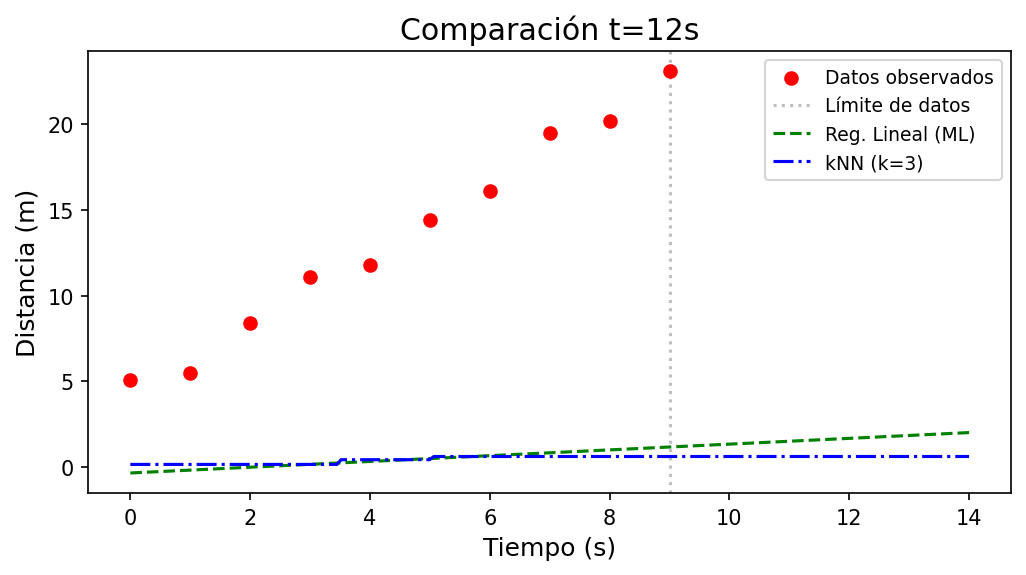

In [16]:
# Visualizamos los tres modelos en rango extendido
plt.figure(figsize=(7, 4))
plt.scatter(x, y, c='red', zorder=5, label='Datos observados')
plt.axvline(x=x.max(), color='gray', linestyle=':', alpha=0.5, label='Límite de datos')
#plt.plot(t_plot, bestm * t_plot + bestb, 'k-', label='Inferencia')
plt.plot(t_plot, regmodel.predict(t_plot), 'g--', label='Reg. Lineal (ML)')
plt.plot(t_plot, knnmodel.predict(t_plot), 'b-.', label='kNN (k=3)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Comparación t=12s')
plt.legend(fontsize=9)
plt.tight_layout()

## Conclusión

Completa la siguiente tabla comparando las dos estrategias:

| | Inferencia estadística | Machine Learning |
|---|---|---|
| ¿Necesita conocer el modelo físico? |Si ya que se basa en el para las predicciones |Aprende y trabaja solo con los datos |
| ¿Entrega los parámetros del modelo? |Si, la velocidad y la distancia |Regresión lineal Si, KNN no |
| ¿Puede extrapolar fuera del rango de datos? |Si el modelo escogido es correcto, si |Reg.lin si , KNN no |
| ¿Cómo maneja las incertezas? |A travez de chi_cuadrado |Por si solo no las considera |
| ¿Cuándo la usarías en tu investigación? |Si conociera el modelo que describe al fenomeno con certeza |Cuando la muestra fuera de tamaño considerable y desconozco el modelo que la describe|

**Pregunta final:** Si la relación fuera sinusoidal en vez de lineal (por ejemplo,
el movimiento de un péndulo), ¿qué estrategia funcionaría mejor?
Prueba cambiando `y = 2*x + 5 + ruido` por `y = np.sin(x) + ruido` al inicio.

**Tu respuesta:**

creo que al ser sinusoidal la estrategia de  la inferencia estadistica funcionaria mejor